In [2]:
import sys
from pathlib import Path

import json
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

# UMAP + PCA
import umap
from sklearn.decomposition import PCA

# Ensure we can import repo modules (main.py, etc.)
REPO_ROOT = Path(".").resolve()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from main import Location2TextLightningModule

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
ckpt_path = Path("location2text_pretrained.ckpt")  # adjust if needed

model = Location2TextLightningModule(
    location_model_type="geoclip",
    location_model=None,
    location_model_filename=None,
    text_model_type="geoclip",
    text_model="geoclip",
    text_vocabulary="openai",
    finetune_mode="none",
    train_text_model=False,
    learning_rate=1e-4,
    weight_decay=1e-2,
    logit_scale_temperature=0.07,
    lambda_alignment=1.0,
    sigma=1.0,
)

if ckpt_path.exists():
    ckpt = torch.load(str(ckpt_path), map_location=device, weights_only=False)
    state_dict = ckpt["state_dict"] if "state_dict" in ckpt else ckpt
    model.load_state_dict(state_dict, strict=False)
else:
    print(f"Checkpoint not found at {ckpt_path}. Using GeoCLIP init weights only.")

model = model.to(device).eval()
print("device:", device)
print("output_dim:", model.output_dim)

train_text_model False


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
The image processor of type `CLIPImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/590 [00:00<?, ?it/s]

CLIPModel LOAD REPORT from: openai/clip-vit-large-patch14
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 
text_model.embeddings.position_ids   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


device: cuda
output_dim: 512


In [4]:
dataset_csv = Path("../../data/s2-100k/ee-dataset/dataset.csv").resolve()  # adjust
df = pd.read_csv(dataset_csv)

need = {"lat", "lon", "description"}
missing = need - set(df.columns)
if missing:
    raise ValueError(f"CSV missing columns: {missing}")

# sample for speed (set to None to use all)
num_samples = 20000
if num_samples is not None and len(df) > num_samples:
    df = df.sample(n=num_samples, random_state=0).reset_index(drop=True)

df.head()

,fn,lat,lon,description
0,patch_94531.tif,-26.232579,30.180958,"This point is in South Africa, Mpumalanga, has..."
1,patch_16197.tif,21.114689,42.474111,"This point is in Saudi Arabia, Makkah, has mou..."
2,patch_38677.tif,14.265058,9.483883,"This point is in Niger, Zinder, has platform/h..."
3,patch_51900.tif,20.513255,2.667809,"This point is in Algeria, Tamanrasset, has mou..."
4,patch_9213.tif,-11.691121,-64.652134,"This point is in Brazil, Rondonia, has lowland..."


In [6]:
@torch.no_grad()
def embed_locations_df(model, df, device, batch_size=512):
    coords = torch.tensor(df[["lat", "lon"]].values.astype("float32"), device=device)
    loader = DataLoader(coords, batch_size=batch_size, shuffle=False)
    out = []
    for batch in tqdm(loader, desc="Embedding locations"):
        out.append(model.location_model(batch))  # already normalized in modeling.py
    return torch.cat(out, dim=0)

@torch.no_grad()
def embed_texts(model, texts, device, batch_size=256, normalize=True):
    out = []
    for i in tqdm(range(0, len(texts), batch_size), desc="Embedding texts"):
        chunk = texts[i:i+batch_size]
        emb = model.text_model_predict(chunk, normalize=normalize)
        if emb.ndim == 1:
            emb = emb.unsqueeze(0)
        out.append(emb)
    return torch.cat(out, dim=0)

def center_and_renorm(X, do_center: bool):
    # Like inference_splice.py: mean-center then L2-normalize
    X = F.normalize(X, dim=1)
    if not do_center:
        return X
    X = X - X.mean(dim=0, keepdim=True)
    return F.normalize(X, dim=1)

def umap_2d(X_np, pca_dim=50, n_neighbors=30, min_dist=0.05, metric="cosine"):
    # PCA pre-step is usually helpful for speed/stability
    if pca_dim is not None:
        p = min(pca_dim, X_np.shape[1], X_np.shape[0] - 1)
        if p >= 2:
            X_np = PCA(n_components=p, random_state=0).fit_transform(X_np)
    return umap.UMAP(
        n_neighbors=n_neighbors,
        min_dist=min_dist,
        metric=metric,
        random_state=0,
    ).fit_transform(X_np)

In [15]:
batch_size_loc = 512
batch_size_txt = 256

loc_emb = embed_locations_df(model, df, device=device, batch_size=batch_size_loc)

loc_emb  = center_and_renorm(loc_emb,  False).cpu()

print("loc_emb:", loc_emb.shape)

Embedding locations: 100%|██████████| 40/40 [00:00<00:00, 161.43it/s]

loc_emb: torch.Size([20000, 512])


# GeoYFCC Text Dataset

In [ ]:
import json
from pathlib import Path

# Load geospatial concepts (list of strings)
geo_path = Path("vocabs/geoyfcc_concept_set.json")
with geo_path.open("r", encoding="utf-8") as f:
    geo_data = json.load(f)

if isinstance(geo_data, dict):
    geo_texts = list(geo_data.keys())
else:
    geo_texts = [str(x) for x in geo_data]

print(f"# geospatial concepts: {len(geo_texts)}")

# Embed them with the same model + preprocessing you used for desc_emb
geo_emb = embed_texts(model, geo_texts, device=device, batch_size=256, normalize=True)
geo_emb = center_and_renorm(geo_emb, False).cpu()

print("geo_emb:", geo_emb.shape)

# geospatial concepts: 10000


Embedding texts: 100%|██████████| 40/40 [00:01<00:00, 33.99it/s]

geo_emb: torch.Size([10000, 512])


In [ ]:
def visualize_embeddings(loc_emb, geo_emb): # plug in uncentered embeddings!
    # If you used do_center=False when computing these:
    # loc_emb_raw: [N, D], desc_emb_raw: [M, D]
    loc_emb_raw = loc_emb
    geo_emb_raw = geo_emb
    print("loc_emb_raw:", loc_emb_raw.shape, "geo_emb_raw:", geo_emb_raw.shape)

    # Mean-centered, renormalized versions
    loc_emb_mc  = center_and_renorm(loc_emb_raw.clone(),  do_center=True)
    geo_emb_mc  = center_and_renorm(geo_emb_raw.clone(), do_center=True)

    # RAW space
    X_raw = torch.cat([loc_emb_raw, geo_emb_raw], dim=0).numpy()
    Y_raw = umap_2d(X_raw)

    n_loc = len(loc_emb_raw)
    Y_loc_raw  = Y_raw[:n_loc]
    Y_txt_raw  = Y_raw[n_loc:]

    # MEAN-CENTERED space
    X_mc = torch.cat([loc_emb_mc, geo_emb_mc], dim=0).numpy()
    Y_mc = umap_2d(X_mc)

    Y_loc_mc = Y_mc[:n_loc]
    Y_txt_mc = Y_mc[n_loc:]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharex=False, sharey=False)

    # Left: raw
    ax = axes[0]
    ax.scatter(Y_loc_raw[:,0], Y_loc_raw[:,1], s=6, alpha=0.35, label="location (raw)", color="tab:orange")
    ax.scatter(Y_txt_raw[:,0], Y_txt_raw[:,1], s=6, alpha=0.6, label="Concepts (raw)", color="tab:green")
    ax.set_title("UMAP – raw normalized")
    ax.legend()

    # Right: mean-centered
    ax = axes[1]
    ax.scatter(Y_loc_mc[:,0], Y_loc_mc[:,1], s=6, alpha=0.35, label="location (mean-centered)", color="tab:orange")
    ax.scatter(Y_txt_mc[:,0], Y_txt_mc[:,1], s=6, alpha=0.6, label="Concepts (mean-centered)", color="tab:green")
    ax.set_title("UMAP – mean-centered + renorm")
    ax.legend()

    plt.tight_layout()
    plt.show()

loc_emb_raw: torch.Size([20000, 512]) geo_emb_raw: torch.Size([10000, 512])


/media/volume/xAi-data/miniconda3/envs/xai/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/media/volume/xAi-data/miniconda3/envs/xai/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


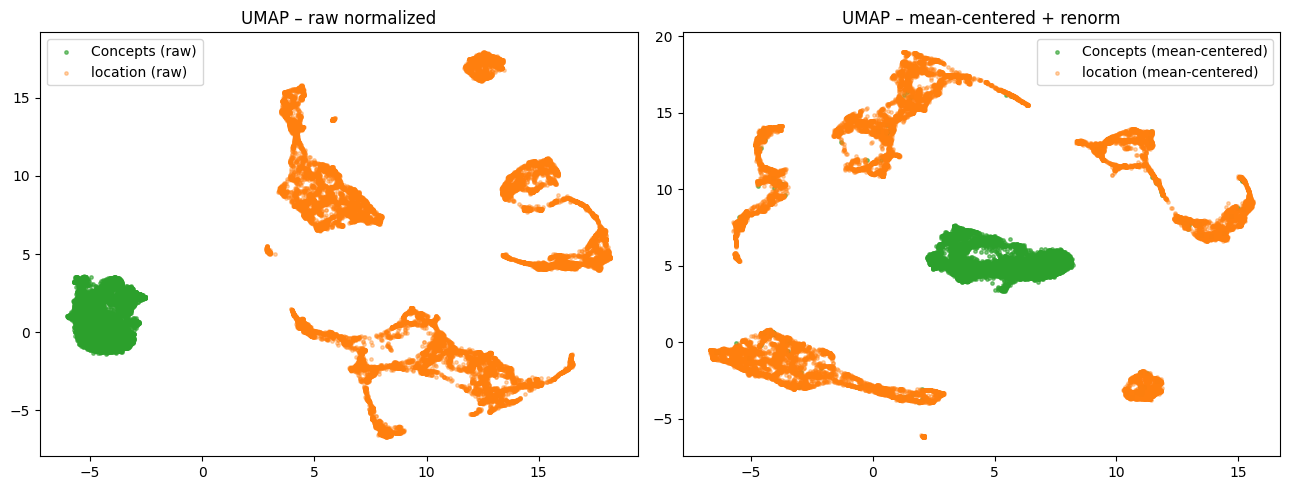

In [20]:
visualize_embeddings(loc_emb, geo_emb)

# MSCOCO Vocab

In [21]:
import json
from pathlib import Path

# Load geospatial concepts (list of strings)
geo_path = Path("vocabs/mscoco.json")
with geo_path.open("r", encoding="utf-8") as f:
    geo_data = json.load(f)

if isinstance(geo_data, dict):
    geo_texts = list(geo_data.keys())
else:
    geo_texts = [str(x) for x in geo_data]

print(f"# geospatial concepts: {len(geo_texts)}")

# Embed them with the same model + preprocessing you used for desc_emb
geo_emb = embed_texts(model, geo_texts, device=device, batch_size=256, normalize=True)
geo_emb = center_and_renorm(geo_emb, False).cpu()

print("geo_emb:", geo_emb.shape)

# geospatial concepts: 12830


Embedding texts: 100%|██████████| 51/51 [00:01<00:00, 43.01it/s]

geo_emb: torch.Size([12830, 512])


In [ ]:
visualize_embeddings(loc_emb, geo_emb)

loc_emb_raw: torch.Size([20000, 512]) geo_emb_raw: torch.Size([12830, 512])


/media/volume/xAi-data/miniconda3/envs/xai/lib/python3.12/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


# Earth-Engine Raster Concepts

## With admin

In [ ]:
import json
from pathlib import Path

# Load geospatial concepts (list of strings)
geo_path = Path("vocabs/satellite_vocab_land.json")
with geo_path.open("r", encoding="utf-8") as f:
    geo_data = json.load(f)

if isinstance(geo_data, dict):
    geo_texts = list(geo_data.keys())
else:
    geo_texts = [str(x) for x in geo_data]

print(f"# geospatial concepts: {len(geo_texts)}")

# Embed them with the same model + preprocessing you used for desc_emb
geo_emb = embed_texts(model, geo_texts, device=device, batch_size=256, normalize=True)
geo_emb = center_and_renorm(geo_emb, False).cpu()

print("geo_emb:", geo_emb.shape)